<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/03_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[⬅ Back to the workshop index](https://github.com/lorenzkap/ML2026#-the-notebooks) · **Notebook 03 of the course**


# 🩺 Notebook 03 — Exploratory Data Analysis (EDA): what predicts death?

> Before we build any model, we *look* at the data. Exploratory Data Analysis (EDA) is where
> the medicine and the statistics meet: we ask **which patients died, and how were they
> different?** — and we let clean, honest plots answer.

**What you'll learn**
- How to measure and visualise **class balance** (only ≈18 % of these sepsis patients died) and why that matters later.
- How to compare **survivors vs non-survivors** for key vitals, labs and severity scores.
- How to read a **correlation heatmap** and spot redundant (multicollinear) features.
- Why **whether a test was ordered** can itself be a signal ("missingness as signal").
- How to plot **trajectories over time** — the moment where non-survivors visibly diverge.

**⏱️ Time:** ≈55 min · **Prerequisites:** Notebooks 01–02 (pandas + cleaning)


## ⚙️ Run me first

This is the standard workshop setup cell — the same one in every notebook. It installs anything
missing, sets a clean plotting style, and defines the data loaders. Just run it and move on.

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 👩‍🏫 INSTRUCTORS: put a direct-download link to the workshop data here (or set the
# WORKSHOP_DATA_URL environment variable) and participants never upload anything.
# It must be a folder-style base URL that serves the CSVs by name, e.g.
#     "https://your-institution.example/sepsis_workshop/"
# Leave it empty ("") to use the upload flow instead. The data is NOT in the public
# GitHub repo on purpose — it is derived from MIMIC-IV and covered by a PhysioNet DUA.
WORKSHOP_DATA_URL = os.environ.get("WORKSHOP_DATA_URL", "")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    paths = [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]
    cache = _drive_cache()
    if cache:
        paths.append(os.path.join(cache, name))
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def _try_download(name):
    """If the instructor configured WORKSHOP_DATA_URL, fetch the file from there."""
    if not WORKSHOP_DATA_URL:
        return None
    import urllib.request
    url = WORKSHOP_DATA_URL.rstrip("/") + "/" + name
    try:
        print(f"⬇  downloading {name} …")
        urllib.request.urlretrieve(url, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV. Searches local folders, (in Colab) your Google-Drive cache, and
    the instructor's download link. If none of those work it asks you to upload the file
    ONCE, then saves a copy to Drive so the other notebooks find it automatically."""
    p = _find(name)
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)
    if p:
        data = pd.read_csv(p)
        print(f"✓ loaded {name}")
        _cache_to_drive(name, data)
        return data
    try:
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Ask your instructor for the workshop CSVs, then either "
            f"upload it when prompted, or put it next to this notebook / in a data/ folder."
        )


### The patient-level table

Most of today's EDA is easiest on **one row per patient**. We'll use the canonical
`build_patient_table` helper (the same one you *build from scratch* in Notebook 04) and the
`load_patients()` loader. It finds the ready-made `sepsis_patients.csv` if it's there, and
otherwise rebuilds it from the time-series file on the fly.

In [2]:
def build_patient_table(ts):
    """Aggregate the 4-hourly time-series into ONE row per ICU stay.
       (This is exactly what Notebook 04 teaches you to build.)"""
    df = ts.copy()
    # clean temperature: prefer Celsius; repair obvious Fahrenheit-entry errors; drop impossible
    tf = df["Temp_F"].where((df["Temp_F"] >= 90) & (df["Temp_F"] <= 110))
    tc = df["Temp_C"].where((df["Temp_C"] >= 25) & (df["Temp_C"] <= 45))
    df["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)
    # impossible vitals -> NaN, then forward/back-fill WITHIN each stay
    for c, lo, hi in [("HR",20,300),("SysBP",40,300),("MeanBP",20,220),("RR",3,80),("SpO2",30,100)]:
        df[c] = df[c].where((df[c] >= lo) & (df[c] <= hi))
    g = df.groupby("icustayid", group_keys=False)
    vit = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean"]
    df[vit] = g[vit].apply(lambda x: x.ffill().bfill())
    # winsorise skewed labs so one stray value can't define a min/max
    for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","INR","Glucose"]:
        lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
        df[c] = df[c].clip(lo, hi)
    tv = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean","GCS","Creatinine","BUN",
          "Arterial_lactate","WBC_count","Platelets_count","Potassium","Sodium",
          "Albumin","INR","Arterial_pH","Shock_Index","SOFA","SIRS","PaO2_FiO2","Hb"]
    grp = df.groupby("icustayid")
    f = {}
    f["age"]=grp["age"].first(); f["gender"]=grp["gender"].first()
    f["elixhauser"]=grp["elixhauser"].first(); f["re_admission"]=grp["re_admission"].first().astype(int)
    f["weight_kg"]=grp["Weight_kg"].median(); f["n_blocs"]=grp.size(); f["los_hours"]=grp["bloc"].max()*4
    f["mechvent_ever"]=grp["mechvent"].max(); f["vaso_max"]=grp["max_dose_vaso"].max()
    f["fluid_balance_last"]=grp["cumulated_balance"].last(); f["urine_total"]=grp["output_step"].sum()
    for c in tv:
        f[f"{c}_mean"]=grp[c].mean(); f[f"{c}_min"]=grp[c].min()
        f[f"{c}_max"]=grp[c].max();  f[f"{c}_last"]=grp[c].last()
    for c in ["Creatinine","Arterial_lactate","SOFA","Shock_Index","GCS"]:
        f[f"{c}_delta"]=grp[c].last()-grp[c].first()
    X = pd.DataFrame(f); X["morta_90"]=grp["morta_90"].max(); X["died_in_hosp"]=grp["died_in_hosp"].max()
    return X.reset_index()

def load_patients():
    p = _find("sepsis_patients.csv")
    if p:
        print(f"✓ loaded {p}"); return pd.read_csv(p)
    print("sepsis_patients.csv not found — building it from the time-series file…")
    return build_patient_table(load_csv("sepsis_timeseries.csv"))


Now load **both** tables — the longitudinal one (`df`, one row per 4-hour block) and the
patient-level one (`patients`, one row per ICU stay).

In [3]:
df = load_csv("sepsis_timeseries.csv")
patients = load_patients()

print("time-series :", df.shape, "  (rows = patient × 4-hour block)")
print("patients    :", patients.shape, "  (rows = ICU stays)")
patients.head()

✓ loaded data/sepsis_timeseries.csv
✓ loaded data/sepsis_patients.csv
time-series : (37704, 53)   (rows = patient × 4-hour block)
patients    : (1696, 107)   (rows = ICU stays)


,icustayid,age,gender,elixhauser,re_admission,weight_kg,n_blocs,los_hours,mechvent_ever,vaso_max,fluid_balance_last,urine_total,HR_mean,HR_min,HR_max,HR_last,SysBP_mean,SysBP_min,SysBP_max,SysBP_last,MeanBP_mean,MeanBP_min,MeanBP_max,MeanBP_last,RR_mean,RR_min,RR_max,RR_last,SpO2_mean,SpO2_min,SpO2_max,SpO2_last,Temp_C_clean_mean,Temp_C_clean_min,Temp_C_clean_max,Temp_C_clean_last,GCS_mean,GCS_min,GCS_max,GCS_last,Creatinine_mean,Creatinine_min,Creatinine_max,Creatinine_last,BUN_mean,BUN_min,BUN_max,BUN_last,Arterial_lactate_mean,Arterial_lactate_min,Arterial_lactate_max,Arterial_lactate_last,WBC_count_mean,WBC_count_min,WBC_count_max,WBC_count_last,Platelets_count_mean,Platelets_count_min,Platelets_count_max,Platelets_count_last,Potassium_mean,Potassium_min,Potassium_max,Potassium_last,Sodium_mean,Sodium_min,Sodium_max,Sodium_last,Albumin_mean,Albumin_min,Albumin_max,Albumin_last,INR_mean,INR_min,INR_max,INR_last,Arterial_pH_mean,Arterial_pH_min,Arterial_pH_max,Arterial_pH_last,Shock_Index_mean,Shock_Index_min,Shock_Index_max,Shock_Index_last,SOFA_mean,SOFA_min,SOFA_max,SOFA_last,SIRS_mean,SIRS_min,SIRS_max,SIRS_last,PaO2_FiO2_mean,PaO2_FiO2_min,PaO2_FiO2_max,PaO2_FiO2_last,Hb_mean,Hb_min,Hb_max,Hb_last,Creatinine_delta,Arterial_lactate_delta,SOFA_delta,Shock_Index_delta,GCS_delta,morta_90,died_in_hosp
0,30003226,67,0,4,0,91.8,12,48,0,0.00,3679.19,625.0,73.3108,64.00,84.20,84.20,137.5183,114.75,169.50,137.00,95.4717,87.25,106.86,90.8,15.5775,12.75,20.80,20.80,96.6708,93.00,99.50,97.00,37.4842,36.67,37.98,36.67,15.0000,15.0,15.0,15.0,11.4490,0.6,12.4388,12.4388,54.4950,13.0,64.0,58.0,1.0617,0.6,2.00,1.7,7.7700,6.60,9.3000,6.6,220.8333,183.00,357.0,183.0,5.4108,2.9,6.80,5.4,135.2933,132.00,149.0,132.0,2.8583,2.30,3.3,3.3,1.4392,1.00,3.1,3.1,7.3458,7.22,7.45,7.32,0.5408,0.39,0.65,0.61,4.8333,1,7,5,0.1667,0,1,1,387.0475,177.78,1342.86,200.00,7.0667,6.6,8.00,6.6,11.8388,-0.30,4,0.02,0.0,0,0
1,30004576,36,0,2,0,87.0,7,28,0,0.00,-2170.00,2350.0,95.7071,89.00,108.33,89.00,126.0271,121.00,138.83,121.00,82.4829,79.00,88.86,79.0,16.5686,12.40,24.00,24.00,97.6457,96.00,99.00,99.00,37.0771,36.44,37.74,36.44,11.5714,3.0,15.0,3.0,0.7000,0.4,0.9000,0.9000,12.8571,8.0,21.0,12.0,2.3286,0.7,3.30,3.3,19.1047,6.10,81.3326,6.1,325.8571,227.00,357.0,357.0,3.8429,3.5,4.40,3.8,139.5714,136.00,143.0,140.0,3.3000,2.70,3.5,3.5,1.3571,1.10,1.4,1.4,7.4429,7.35,7.48,7.48,0.7586,0.74,0.79,0.74,2.7143,0,5,5,1.2857,1,2,1,440.0100,188.89,848.30,338.10,8.6486,8.6,8.73,8.6,0.4000,2.60,5,-0.01,-12.0,0,0
2,30004811,66,0,4,0,63.5,14,56,1,0.36,1798.03,5945.0,83.1407,74.96,96.00,96.00,105.3293,90.57,127.75,111.00,70.3364,59.17,86.57,71.0,18.7000,11.83,25.00,25.00,98.3836,96.83,99.91,97.00,36.9043,36.63,37.22,37.22,12.3079,6.0,15.0,6.0,1.1164,0.6,5.8000,0.9000,14.9807,11.0,32.0,17.0,2.1829,0.7,3.00,1.4,7.0707,4.25,18.5000,6.9,161.6471,104.00,235.0,157.0,4.5557,3.6,5.91,4.2,135.9700,134.00,137.0,135.0,2.7400,2.33,4.0,4.0,1.3164,1.03,1.4,1.2,7.4521,7.37,7.47,7.47,0.7971,0.59,0.93,0.86,4.5714,1,8,5,0.5000,0,2,2,342.7336,48.04,933.80,292.86,9.3464,8.0,10.41,10.0,0.1000,-1.60,2,0.27,-9.0,0,0
3,30009596,77,1,4,0,72.0,9,36,0,0.00,-1650.00,2750.0,60.8400,53.00,83.89,69.33,169.9000,159.25,185.18,174.83,98.9267,87.25,113.33,102.0,15.7056,14.00,18.00,17.00,95.1256,92.40,97.22,96.00,36.9778,36.89,37.17,36.91,12.8889,6.0,15.0,6.0,0.9111,0.6,2.2000,0.7000,15.8889,8.0,31.0,11.0,1.3644,0.7,2.78,1.0,8.9000,6.40,14.3000,10.0,279.1856,65.67,466.0,466.0,3.9889,3.5,4.40,4.1,141.1856,134.00,147.0,147.0,3.3267,2.70,3.9,3.9,1.3333,1.10,2.3,1.1,7.4300,7.32,7.51,7.49,0.3578,0.30,0.51,0.40,3.1111,1,8,3,0.3333,0,1,0,404.2200,134.68,942.71,407.64,10.9078,7.5,12.30,12.3,0.0000,-1.78,1,0.06,-9.0,0,0
4,30011748,70,0,2,0,91.0,5,20,0,0.00,50.00,950.0,71.0900,67.43,75.12,75.12,141.9080,134.86,148.88,148.88,97.8180,90.29,105.50,105.5,16.3980,11.43,21.33,16.88,97.9040,96.60,99.50,98.12,35.7980,35.63,36.11,35.72,15.0000,15.0,15.0,15.0,1.1300,0.9,1.2000,1.2000,21.3000,13.0,27.5,22.0,1.0600,0.6,2.40,0.6,5.8

## ⚖️ Class balance — how many patients died?

The very first question in any prediction problem: **how common is the outcome?** Our target is
`morta_90` (died within 90 days = 1). Let's count.

In [4]:
rate = patients["morta_90"].mean()
counts = patients["morta_90"].value_counts().sort_index()
print(counts.rename({0: "survived", 1: "died"}))
print(f"\n90-day mortality rate: {rate:.1%}  ({counts.get(1,0)} of {len(patients)} stays)")

morta_90
survived    1387
died         309
Name: count, dtype: int64

90-day mortality rate: 18.2%  (309 of 1696 stays)


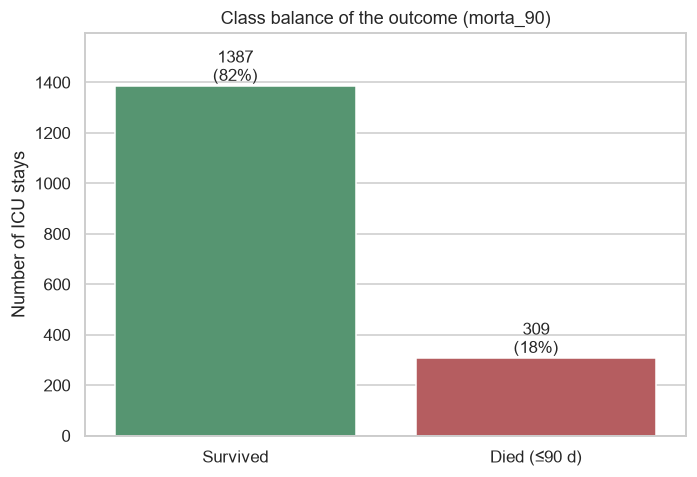

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
order = [0, 1]
sns.countplot(x="morta_90", data=patients, order=order,
              palette=["#4C9F70", "#C44E52"], ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Survived", "Died (≤90 d)"])
ax.set_xlabel(""); ax.set_ylabel("Number of ICU stays")
ax.set_title("Class balance of the outcome (morta_90)")
for p in ax.patches:
    n = int(p.get_height())
    ax.annotate(f"{n}\n({n/len(patients):.0%})",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
ax.margins(y=0.15)
plt.tight_layout(); plt.show()

> **🧠 Clinical takeaway.** The classes are **imbalanced**: roughly **1 in 5** patients died,
> 4 in 5 survived. A lazy model that predicts *"everyone survives"* would already be ≈82 % accurate
> — yet it would miss *every single death*. That's why in Notebook 06 we'll judge models with
> **ROC-AUC, precision–recall and calibration**, not raw accuracy. Keep this number (≈18 %) in mind.

## 🔬 Survivors vs non-survivors — where do they differ?

Now the heart of EDA: overlay the distribution of a feature for those who **survived** vs those
who **died**, and see where the curves separate. A clean separation means the feature carries
predictive signal.

We'll add a readable `Outcome` label so legends say *Survived / Died* instead of `0 / 1`.

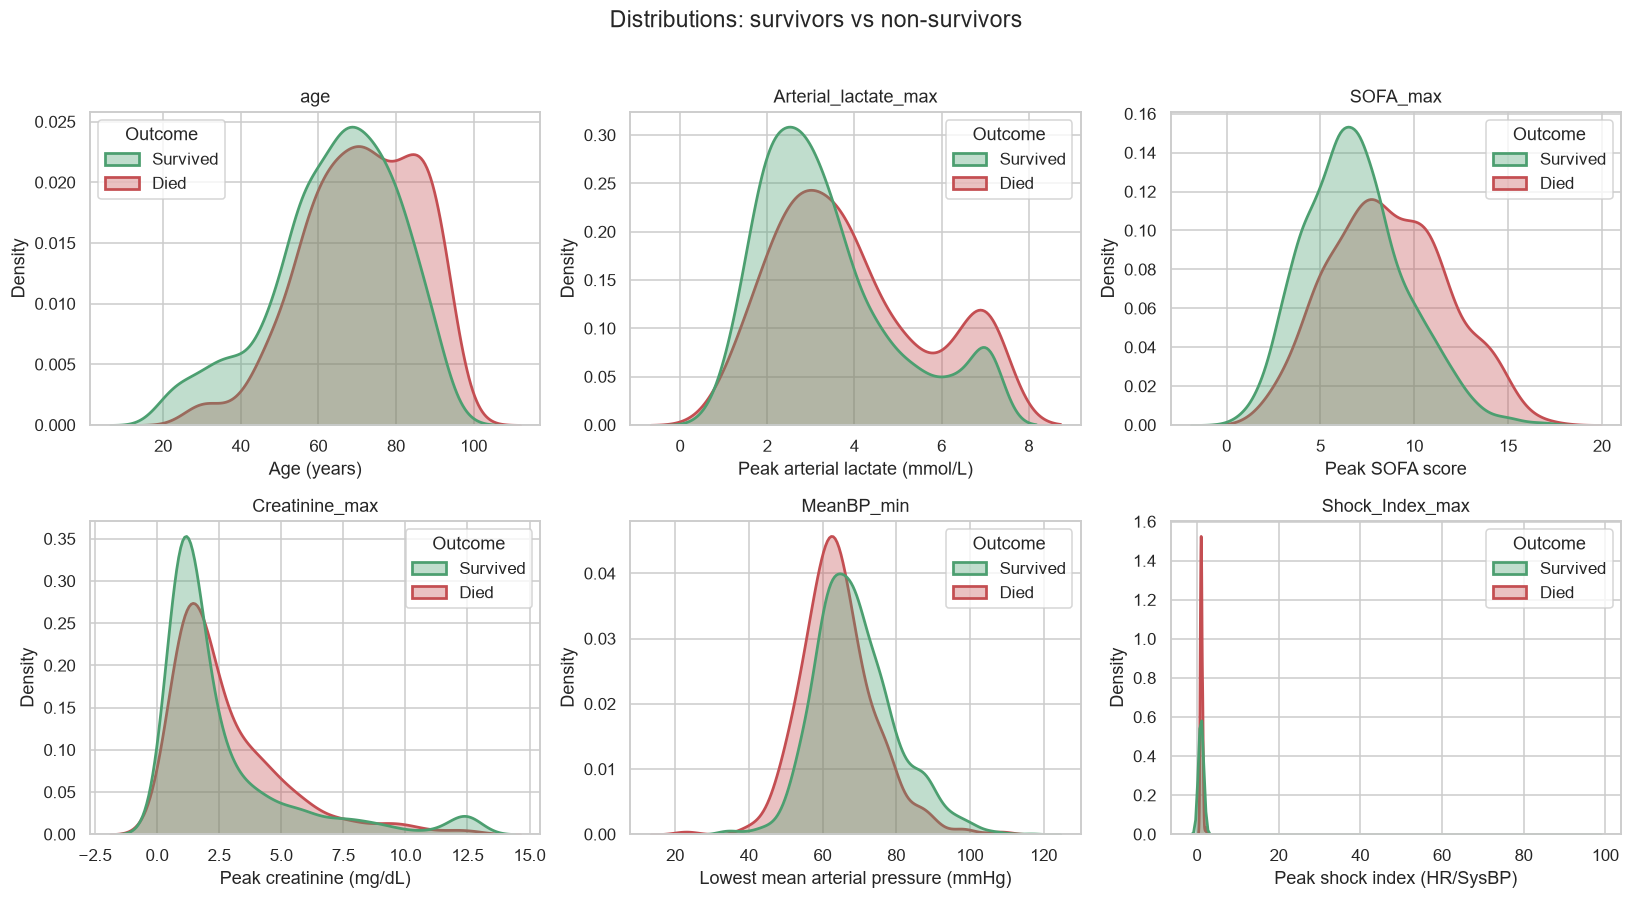

In [6]:
patients = patients.assign(
    Outcome=patients["morta_90"].map({0: "Survived", 1: "Died"})
)
PALETTE = {"Survived": "#4C9F70", "Died": "#C44E52"}

features = [
    ("age",                   "Age (years)"),
    ("Arterial_lactate_max",  "Peak arterial lactate (mmol/L)"),
    ("SOFA_max",              "Peak SOFA score"),
    ("Creatinine_max",        "Peak creatinine (mg/dL)"),
    ("MeanBP_min",            "Lowest mean arterial pressure (mmHg)"),
    ("Shock_Index_max",       "Peak shock index (HR/SysBP)"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, label) in zip(axes.ravel(), features):
    sns.kdeplot(data=patients, x=col, hue="Outcome", hue_order=["Survived", "Died"],
                palette=PALETTE, common_norm=False, fill=True, alpha=0.35,
                linewidth=1.8, ax=ax)
    ax.set_xlabel(label); ax.set_ylabel("Density")
    ax.set_title(col)
fig.suptitle("Distributions: survivors vs non-survivors", fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

Read each panel as *"do the red (Died) and green (Survived) curves overlap, or separate?"*

- **Lactate, SOFA, creatinine, shock index** are all shifted **right** (higher) for non-survivors —
  classic markers of tissue hypoxia, organ failure and kidney injury.
- **Lowest MAP** is shifted **left** for non-survivors — they spent time more profoundly hypotensive.
- **Age** separates only mildly here — sepsis kills across the age range.

Distributions show *shape*; a **boxplot / violin** shows the medians and spread side by side. Let's
quantify the four strongest separators.

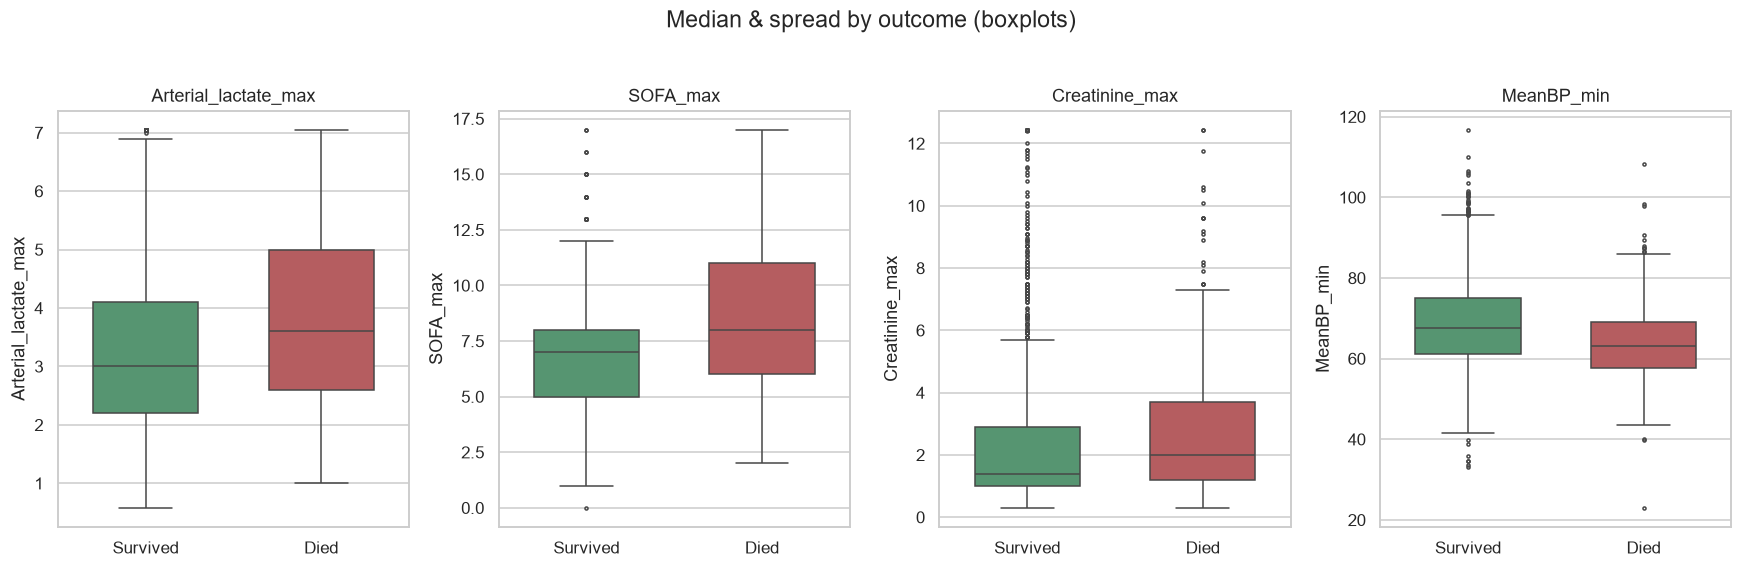

Outcome,Died (median),Survived (median),abs. gap
Arterial_lactate_max,3.60,3.0,0.60
SOFA_max,8.00,7.0,1.00
Creatinine_max,2.00,1.4,0.60
MeanBP_min,63.17,67.5,4.33


In [7]:
strong = ["Arterial_lactate_max", "SOFA_max", "Creatinine_max", "MeanBP_min"]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, strong):
    sns.boxplot(data=patients, x="Outcome", y=col, order=["Survived", "Died"],
                palette=PALETTE, width=0.6, fliersize=2, ax=ax)
    ax.set_xlabel(""); ax.set_title(col)
fig.suptitle("Median & spread by outcome (boxplots)", fontsize=15, y=1.03)
plt.tight_layout(); plt.show()

# a compact numeric summary of the same comparison
summary = (patients.groupby("Outcome")[strong]
           .median().T.rename(columns=lambda c: f"{c} (median)"))
summary["abs. gap"] = (summary["Died (median)"] - summary["Survived (median)"]).abs().round(2)
summary.round(2)

> **🧠 Clinical takeaway.** Peak **lactate** and peak **SOFA** show the biggest gap between the
> groups — exactly the two things you'd reach for at the bedside to say *"this septic patient is in
> trouble."* Good EDA and good clinical intuition agree, which is reassuring before we hand the
> problem to a model.

### ✏️ Your turn 1 — pick your own marker

Choose a feature we **haven't** plotted (e.g. `GCS_min`, `Arterial_pH_min`, `Albumin_min`,
`WBC_count_max`, `Platelets_count_min`) and draw a KDE split by `Outcome`. Does it separate the
groups? Does the direction match your clinical expectation?

In [8]:
# TODO: choose a column and make a KDE split by Outcome
# my_col = "GCS_min"
# sns.kdeplot(...)


<details><summary>💡 Show solution</summary>

```python
my_col = "GCS_min"   # lowest Glasgow Coma Scale during the stay
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.kdeplot(data=patients, x=my_col, hue="Outcome", hue_order=["Survived", "Died"],
            palette=PALETTE, common_norm=False, fill=True, alpha=0.35, ax=ax)
ax.set_xlabel("Lowest GCS during stay (3–15)")
ax.set_title(f"{my_col} by outcome")
plt.tight_layout(); plt.show()

print(patients.groupby("Outcome")[my_col].median())
# Non-survivors have a LOWER minimum GCS (more depressed consciousness) — as expected.
```
</details>

### ✏️ Your turn 2 — mortality rate by age band

Distributions are one lens; a **rate** is another. Use `pd.cut` to bin `age` into decades and
compute the mortality rate within each band, then plot it. Does mortality climb with age?

In [9]:
# TODO: create an age band with pd.cut, then group and take the mean of morta_90
# bands = pd.cut(patients["age"], bins=[0,40,50,60,70,80,120])
# ...


<details><summary>💡 Show solution</summary>

```python
bands = pd.cut(patients["age"], bins=[0, 40, 50, 60, 70, 80, 120],
               labels=["<40", "40–49", "50–59", "60–69", "70–79", "80+"])
rate_by_age = patients.groupby(bands)["morta_90"].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(x=rate_by_age.index, y=rate_by_age.values, color="#4C72B0", ax=ax)
ax.set_xlabel("Age band"); ax.set_ylabel("90-day mortality rate")
ax.set_title("Mortality rate by age band")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout(); plt.show()
print(rate_by_age.round(3))
# Mortality rises with age, but every band still loses patients — age alone is a weak predictor.
```
</details>

## 🌡️ Correlation heatmap — which features move together?

When we build models, features that are **highly correlated** carry overlapping information. This
isn't fatal, but it makes coefficients unstable and importances harder to read. Let's look at a
curated set of patient-level features.

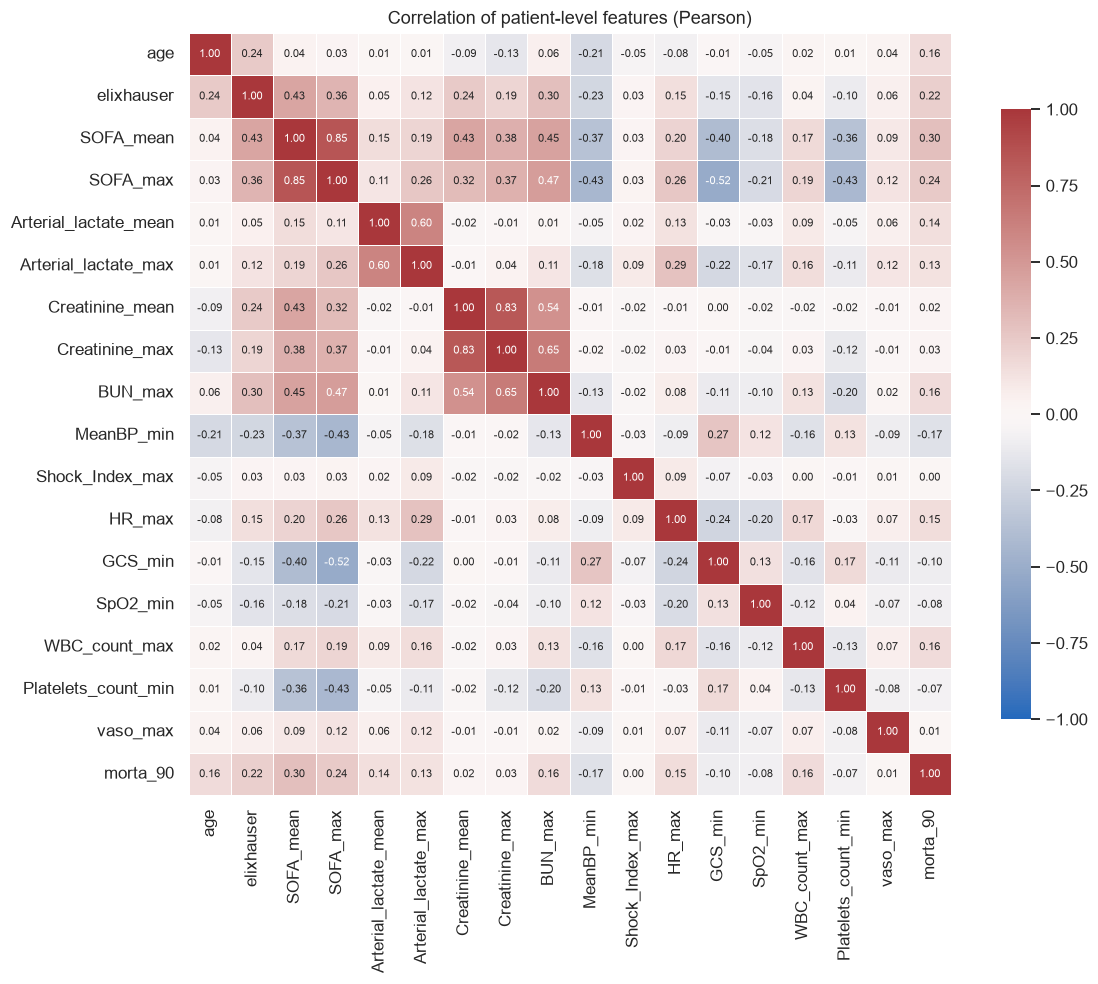

In [10]:
corr_cols = [
    "age", "elixhauser", "SOFA_mean", "SOFA_max",
    "Arterial_lactate_mean", "Arterial_lactate_max",
    "Creatinine_mean", "Creatinine_max", "BUN_max",
    "MeanBP_min", "Shock_Index_max", "HR_max",
    "GCS_min", "SpO2_min", "WBC_count_max", "Platelets_count_min",
    "vaso_max", "morta_90",
]
corr = patients[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .8},
            annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation of patient-level features (Pearson)")
plt.tight_layout(); plt.show()

Two things to notice:

1. **Blocks of dark colour = redundancy.** `SOFA_mean` vs `SOFA_max`, `Creatinine_mean` vs
   `Creatinine_max`, `Arterial_lactate_mean` vs `_max` — the *mean/last/max of the same variable*
   are strongly correlated. That's **multicollinearity**. A tree model shrugs; a linear model
   prefers you prune or regularise.
2. **The `morta_90` column** (bottom row) shows the *univariate* link of each feature to death:
   SOFA, lactate, shock index and vasopressor dose stand out as positively correlated with mortality.

> **🧠 Clinical takeaway.** Correlation ≠ causation, and a heatmap only sees **linear** pairwise
> relationships. Use it to *prune redundancy* and *sanity-check direction*, not to decide biology.

## 🕳️ Missingness as signal — the test you *ordered* is information

In real clinical data, **whether a value exists is not random.** Sicker patients get more blood
gases, more lines, more labs. So the *presence* of a measurement can predict outcome — even before
you look at the value.

`SaO2` (arterial oxygen saturation) comes from an **ABG — an *arterial blood gas*, a blood test that
measures a patient's oxygen, carbon dioxide and acid–base status**. It is missing ≈94 % of the time,
because an ABG is only drawn when a clinician judges it warranted. Let's ask: **do patients who ever had an
SaO2 measured die more often?**

In [11]:
g = df.groupby("icustayid")
sao2_ever  = g["SaO2"].apply(lambda s: s.notna().any())      # was ABG SaO2 ever drawn?
height_ever = g["Height_cm"].apply(lambda s: s.notna().any()) # was height ever recorded?
mort = g["morta_90"].max()

flags = pd.DataFrame({
    "SaO2 ever measured (ABG)": sao2_ever.map({True: "Yes", False: "No"}),
    "Height ever recorded":     height_ever.map({True: "Yes", False: "No"}),
    "morta_90": mort,
})

for col in ["SaO2 ever measured (ABG)", "Height ever recorded"]:
    print(col)
    print(flags.groupby(col)["morta_90"].agg(["mean", "size"]).rename(
        columns={"mean": "mortality", "size": "n"}).round(3), "\n")

SaO2 ever measured (ABG)
                          mortality     n
SaO2 ever measured (ABG)                 
No                            0.175  1305
Yes                           0.207   391 

Height ever recorded
                      mortality    n
Height ever recorded                
No                        0.173  881
Yes                       0.193  815 



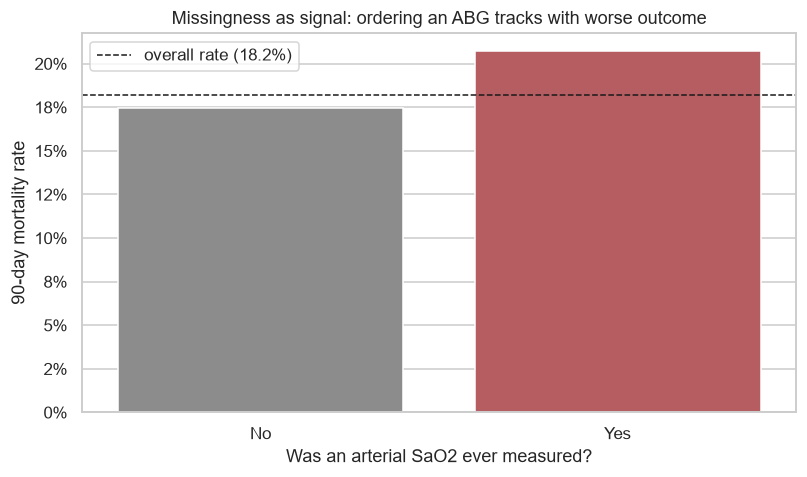

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_df = flags.groupby("SaO2 ever measured (ABG)")["morta_90"].mean().reindex(["No", "Yes"])
sns.barplot(x=plot_df.index, y=plot_df.values, palette=["#8C8C8C", "#C44E52"], ax=ax)
ax.axhline(mort.mean(), ls="--", color="k", lw=1,
           label=f"overall rate ({mort.mean():.1%})")
ax.set_xlabel("Was an arterial SaO2 ever measured?")
ax.set_ylabel("90-day mortality rate")
ax.set_title("Missingness as signal: ordering an ABG tracks with worse outcome")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend()
plt.tight_layout(); plt.show()

The effect is modest but real: patients who had an arterial blood gas drawn died **more** often
— because the *decision to order the test* encodes the clinician's concern.

> **🧠 Clinical takeaway.** This cuts two ways. It's a **genuine feature** ("was an ABG ordered?"),
> but it's also a **leakage trap**: if the test is ordered *because* the patient is already dying,
> a model can look brilliant in-sample and fail on a hospital that orders tests differently. We
> return to this danger in Notebook 08. When you impute a column (Notebook 02), consider also
> keeping a `was_measured` flag — you may be throwing away signal.

## 📈 Trajectories over time — where non-survivors diverge

So far we've collapsed each patient to one row. But this is **time-series** data — and the most
powerful EDA plot here shows how a marker *evolves* over the ICU stay, split by outcome.

We go back to the longitudinal `df` and average each variable at every 4-hour `bloc`, separately
for survivors and non-survivors. Seaborn's `lineplot` draws the mean **and** a 95 % confidence band
for free. We limit to the first ≈20 blocks (≈80 h), where most patients still have data.

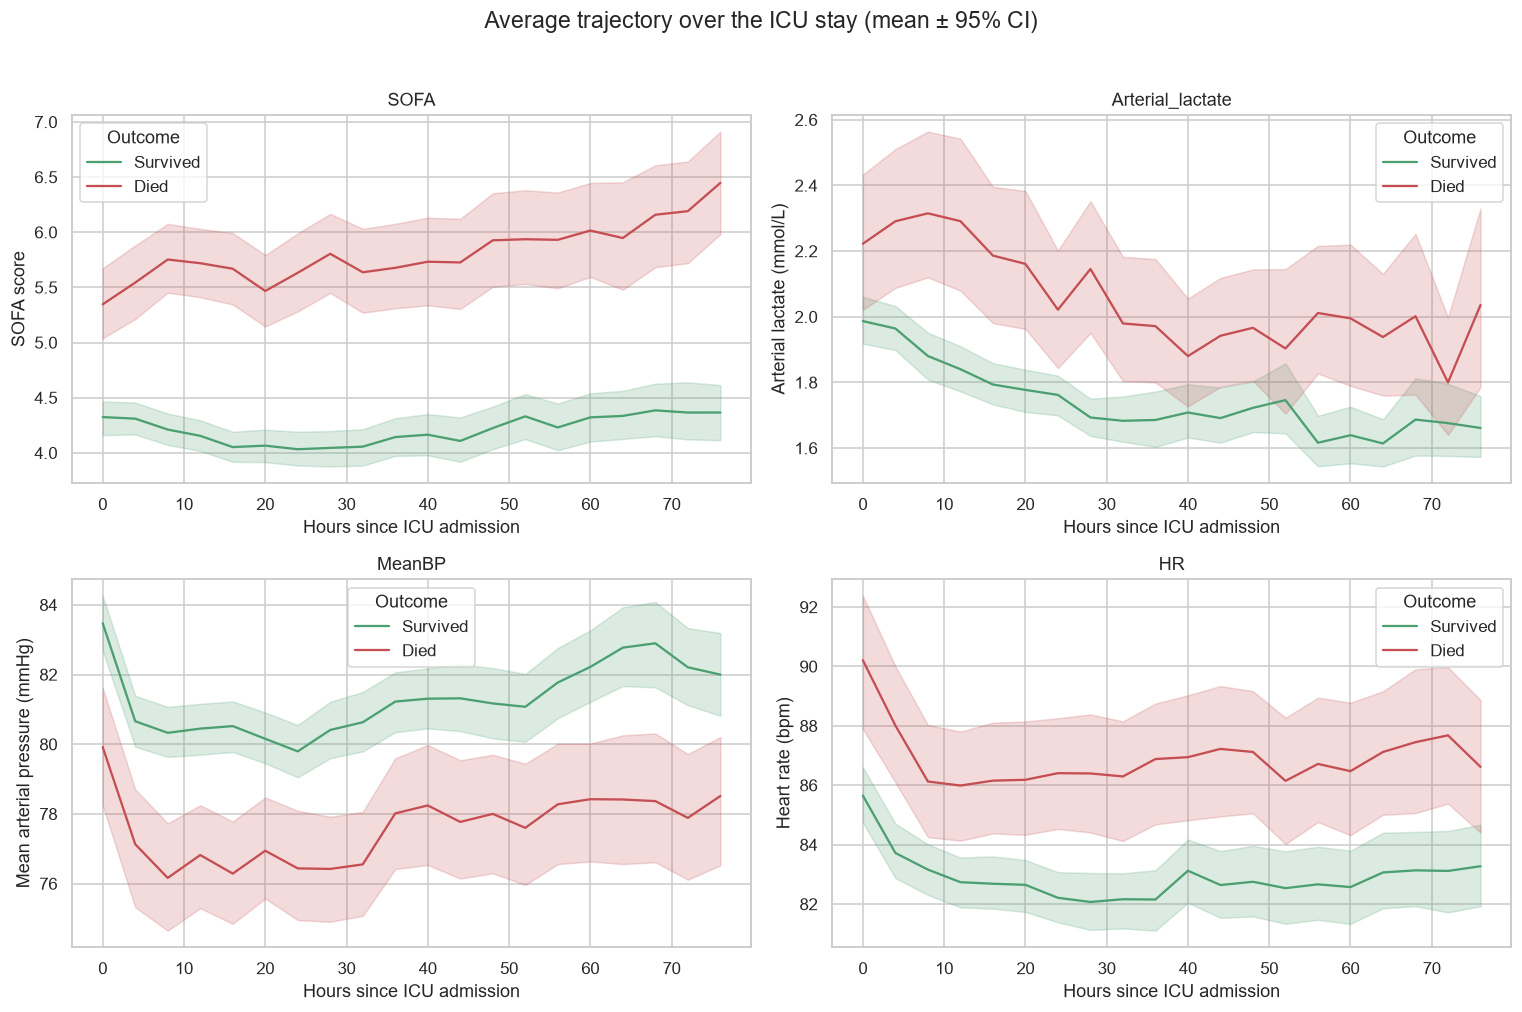

In [13]:
ts = df.copy()
ts["Outcome"] = ts["morta_90"].map({0: "Survived", 1: "Died"})
ts["hours"] = (ts["bloc"] - 1) * 4          # 0 h at first block
early = ts[ts["bloc"] <= 20]                 # first ~80 hours

traj = [
    ("SOFA",             "SOFA score"),
    ("Arterial_lactate", "Arterial lactate (mmol/L)"),
    ("MeanBP",           "Mean arterial pressure (mmHg)"),
    ("HR",               "Heart rate (bpm)"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (col, label) in zip(axes.ravel(), traj):
    sns.lineplot(data=early, x="hours", y=col, hue="Outcome",
                 hue_order=["Survived", "Died"], palette=PALETTE,
                 errorbar=("ci", 95), ax=ax)
    ax.set_xlabel("Hours since ICU admission"); ax.set_ylabel(label)
    ax.set_title(col)
fig.suptitle("Average trajectory over the ICU stay (mean ± 95% CI)", fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

This is the picture worth a thousand summary statistics:

- **SOFA** and **lactate** start higher in non-survivors **and stay higher / drift up** — their organ
  failure doesn't resolve.
- **MAP** runs lower in non-survivors despite treatment.
- The **shaded bands** are 95 % confidence intervals: where red and green bands don't overlap, the
  difference is unlikely to be noise.

> **🧠 Clinical takeaway.** It is not just the *level* at admission but the **failure to improve**
> that marks the sickest patients. This is the intuition behind *rate-of-change* and *rolling-trend*
> features — which is exactly what Notebook 04 teaches you to engineer.

### ✏️ Your turn 3 — trajectory of another marker

Plot the average trajectory of a different time-varying variable (e.g. `GCS`, `Shock_Index`,
`SpO2`, `Creatinine`) over the first 20 blocks, split by `Outcome`, with a 95 % CI band. Does it
diverge?

In [14]:
# TODO: use sns.lineplot on `early` with x="hours", hue="Outcome", errorbar=("ci",95)
# my_col = "Shock_Index"


<details><summary>💡 Show solution</summary>

```python
my_col = "Shock_Index"
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.lineplot(data=early, x="hours", y=my_col, hue="Outcome",
             hue_order=["Survived", "Died"], palette=PALETTE,
             errorbar=("ci", 95), ax=ax)
ax.set_xlabel("Hours since ICU admission")
ax.set_ylabel("Shock index (HR / SysBP)")
ax.set_title("Shock-index trajectory by outcome")
plt.tight_layout(); plt.show()
# Non-survivors sit at a higher shock index and it resolves more slowly — persistent shock.
```
</details>

## 👥 Small multiples — real individual patients

Averages hide individuals. Let's pick a few real stays — some survivors, some non-survivors — and
plot **one patient per panel**, showing lactate and MAP together, to feel the variability behind the
smooth average curves.

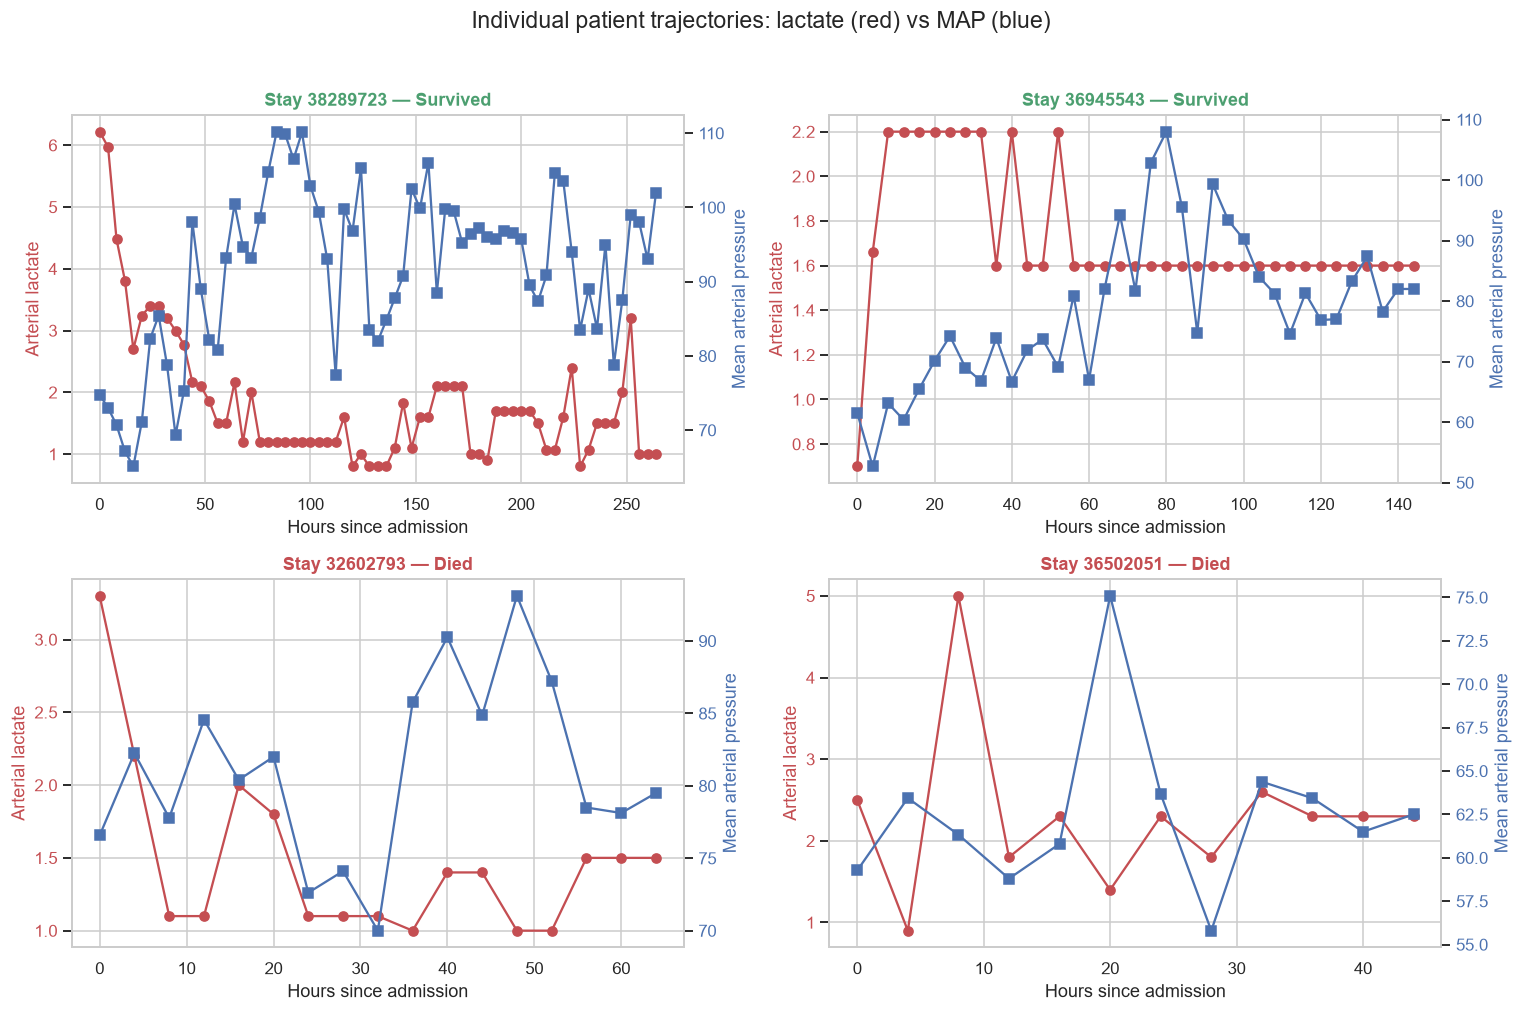

In [15]:
# choose long-enough stays: 2 survivors and 2 non-survivors with many blocks
stay_len = df.groupby("icustayid")["bloc"].max()
outcome_by_stay = df.groupby("icustayid")["morta_90"].max()
long_stays = stay_len[stay_len >= 12].index

rng = np.random.RandomState(RANDOM_STATE)
surv_ids = rng.choice(outcome_by_stay[(outcome_by_stay == 0) & outcome_by_stay.index.isin(long_stays)].index, 2, replace=False)
died_ids = rng.choice(outcome_by_stay[(outcome_by_stay == 1) & outcome_by_stay.index.isin(long_stays)].index, 2, replace=False)
picked = [(sid, "Survived") for sid in surv_ids] + [(sid, "Died") for sid in died_ids]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (sid, label) in zip(axes.ravel(), picked):
    one = df[df["icustayid"] == sid].sort_values("bloc")
    hrs = (one["bloc"] - 1) * 4
    ax.plot(hrs, one["Arterial_lactate"], marker="o", color="#C44E52", label="Lactate (mmol/L)")
    ax.set_xlabel("Hours since admission"); ax.set_ylabel("Arterial lactate", color="#C44E52")
    ax.tick_params(axis="y", labelcolor="#C44E52")
    ax2 = ax.twinx()
    ax2.plot(hrs, one["MeanBP"], marker="s", color="#4C72B0", label="MeanBP (mmHg)")
    ax2.set_ylabel("Mean arterial pressure", color="#4C72B0")
    ax2.tick_params(axis="y", labelcolor="#4C72B0"); ax2.grid(False)
    colour = PALETTE[label]
    ax.set_title(f"Stay {int(sid)} — {label}", color=colour, fontweight="bold")
fig.suptitle("Individual patient trajectories: lactate (red) vs MAP (blue)", fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

> **🧠 Clinical takeaway.** Individual courses are **noisy**. One survivor may spike a lactate and
> recover; one non-survivor may look deceptively stable early. Models learn from the *whole cohort's*
> patterns — but, as clinicians and researchers both know, a single trajectory can surprise you. That humility is why
> Notebook 06 stresses **calibration** and Notebook 08 stresses **honest validation**.

## ✅ Recap

- **Class balance:** ≈18 % 90-day mortality — imbalanced, so accuracy alone will mislead us.
- **Survivors vs non-survivors:** peak **lactate** and **SOFA** separate the groups most; lower
  **MAP** and higher **shock index / creatinine** follow — all consistent with the medicine.
- **Correlation heatmap:** mean/max/last of the same variable are highly collinear — prune or
  regularise; the `morta_90` row confirms which markers matter univariately.
- **Missingness as signal:** *ordering* a test (an ABG) tracks with worse outcome — useful, but a
  leakage risk to watch.
- **Trajectories:** non-survivors don't just start sicker, they **fail to improve** — motivating
  the rate-of-change and rolling features to come.

## ➡️ Next

**Notebook 04 — Turning a timeline into features.** You'll build the very `sepsis_patients.csv`
table we leaned on here: lags, deltas, rolling windows, cumulative sums and expanding means — all
grouped by patient and all **leakage-aware**. It's the heart of the course.